# Задача 6.1 : Распространение тепла в теле с переменной теплопроводностью

In [63]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.animation as anim

## Параметры задачи

In [64]:
L = 1                           # длинна трубы
Nx = 201                        # кол-во точек по пространству
dt = 0.0005                      # шаг по времени
dx = L/(Nx-1)                   # шаг по пространству
t0 = 0                          # начальный момент времени
t_screen = [ 0.01 , 0.1 , 0.5, 1, 2 ] # в какие моменты времени строить графики
Nt = max(t_screen)/dt           # кол-во шагов по времени
k0 = 0.01                          # постоянная в уравнении распределения теплопроводности
x = np.linspace(0,L,Nx)        # сетка
k = k0 * (1 + 0.5 * np.sin(2 * np.pi * x)) # переменная теплопроводность

## Аналитическое решение

In [65]:
def analitic( x , t , k0 , L , precision=20 ):
    # x - сетка
    # t - вычисляемый момент времени
    # k0 - постоянный коэф. теплопроводности
    # L - длина тела
    # precision - кол-во членов ряда, которые будут использованы
    if( np.fabs(t) < 1.e-8 ):
        return np.zeros_like(x)
    ans = np.ones_like(x)
    for i in range(precision):
        lamda = np.pi*(2*i+1)/(2*L)
        cf = 4/(np.pi*(2*i+1))
        ans -= cf*np.sin(lamda*x)*np.exp( -k0*lamda**2*t)
    return ans

## Метод FTCS

In [66]:
def ftcs( u0 , t0 , t1 , dx , dt , k ):
    u = u0.copy()
    Nt = math.floor((t1-t0)/dt)
    Nx = len(u0)
    dt_last = t1 - t0 - dt*Nt
    u_new = u.copy()
    for i in range(Nt):
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            u_new[i] = u[i] + dt / dx**2 * (
                k_r * (u[i + 1] - u[i]) - k_l * (u[i] - u[i - 1])
            )
        u_new[0] = 1.0
        u_new[-1] = u_new[-2]
        u = u_new.copy()
    if np.fabs(dt_last) > 1.e-8:
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            u_new[i] = u[i] + dt_last / dx**2 * (
                k_r * (u[i + 1] - u[i]) - k_l * (u[i] - u[i - 1])
            )
        u_new[0] = 1.0
        u_new[-1] = u_new[-2]
        u = u_new.copy()
    return u

## Метод Кранка-Николсона

In [67]:
def crank_nicolson( u0 , t0 , t1 , dx , dt , k ):
    Nx = len(u0)
    u = u0.copy()
    Nt = math.floor((t1-t0)/dt)
    dt_last = t1 - t0 - dt*Nt
    u_new = u.copy()
    for n in range(Nt):
        a = np.zeros(Nx - 1)
        b = np.zeros(Nx)
        c = np.zeros(Nx - 1)
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            a[i - 1] = -0.5 * dt / dx**2 * k_l
            c[i] = -0.5 * dt / dx**2 * k_r
            b[i] = 1 + 0.5 * dt / dx**2 * (k_l + k_r)
        b[0] = 1.0
        b[-1] = 1.0

        rhs = u.copy()
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            rhs[i] += 0.5 * dt / dx**2 * (
                k_r * (u[i + 1] - u[i]) - k_l * (u[i] - u[i - 1])
            )

        rhs[0] = 1.0
        rhs[-1] = rhs[-2]

        c_star = np.zeros(Nx - 1)
        d_star = np.zeros(Nx)
        c_star[0] = c[0] / b[0]
        d_star[0] = rhs[0] / b[0]
        for i in range(1, Nx - 1):
            denom = b[i] - a[i - 1] * c_star[i - 1]
            c_star[i] = c[i] / denom
            d_star[i] = (rhs[i] - a[i - 1] * d_star[i - 1]) / denom
        d_star[-1] = (rhs[-1] - a[-2] * d_star[-2]) / (b[-1] - a[-2] * c_star[-2])
        
        u_new = u.copy()
        u_new[-1] = d_star[-1]
        for i in range(Nx - 2, -1, -1):
            u_new[i] = d_star[i] - c_star[i - 1] * u_new[i + 1] if i > 0 else 1.0
        u = u_new.copy()
    if np.fabs(dt_last) > 1.e-8:
        a = np.zeros(Nx - 1)
        b = np.zeros(Nx)
        c = np.zeros(Nx - 1)
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            a[i - 1] = -0.5 * dt_last / dx**2 * k_l
            c[i] = -0.5 * dt_last / dx**2 * k_r
            b[i] = 1 + 0.5 * dt_last / dx**2 * (k_l + k_r)
        b[0] = 1.0
        b[-1] = 1.0

        rhs = u.copy()
        for i in range(1, Nx - 1):
            k_r = 0.5 * (k[i] + k[i + 1])
            k_l = 0.5 * (k[i] + k[i - 1])
            rhs[i] += 0.5 * dt_last / dx**2 * (
                k_r * (u[i + 1] - u[i]) - k_l * (u[i] - u[i - 1])
            )

        rhs[0] = 1.0
        rhs[-1] = rhs[-2]

        c_star = np.zeros(Nx - 1)
        d_star = np.zeros(Nx)
        c_star[0] = c[0] / b[0]
        d_star[0] = rhs[0] / b[0]
        for i in range(1, Nx - 1):
            denom = b[i] - a[i - 1] * c_star[i - 1]
            c_star[i] = c[i] / denom
            d_star[i] = (rhs[i] - a[i - 1] * d_star[i - 1]) / denom
        d_star[-1] = (rhs[-1] - a[-2] * d_star[-2]) / (b[-1] - a[-2] * c_star[-2])
        
        u_new = u.copy()
        u_new[-1] = d_star[-1]
        for i in range(Nx - 2, -1, -1):
            u_new[i] = d_star[i] - c_star[i - 1] * u_new[i + 1] if i > 0 else 1.0
        u = u_new.copy()
    return u

## Вычисления при переменной теплопроводности

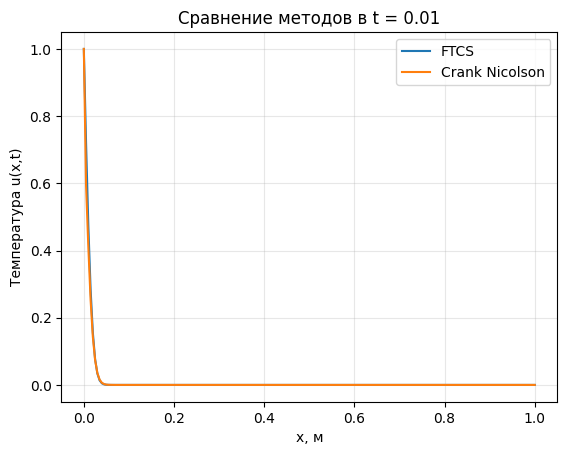

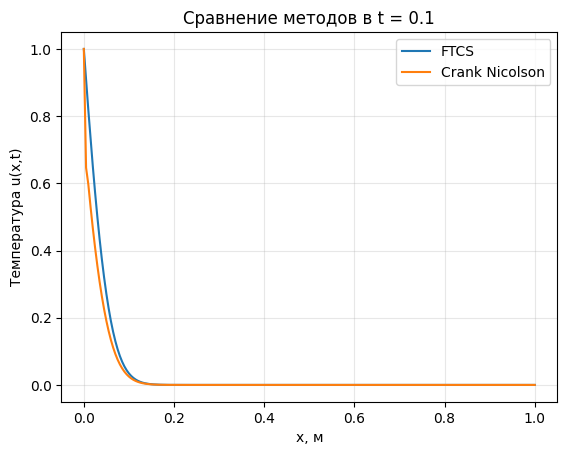

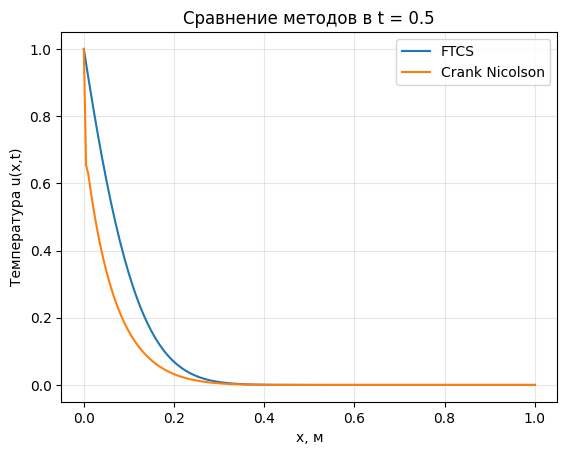

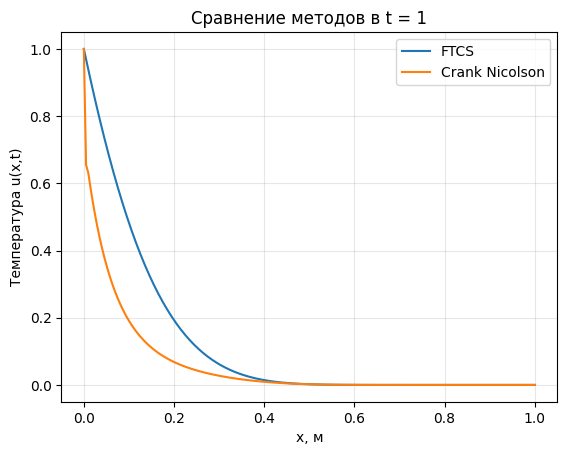

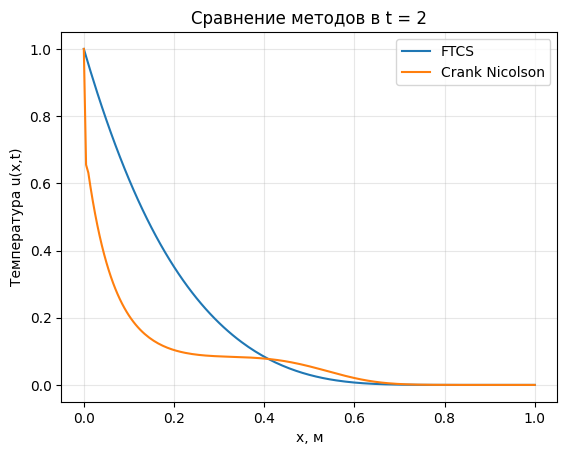

In [68]:
u_ftcs = [np.zeros_like(x)]
t_start = t0
for i in range(len(t_screen)):
    u_ftcs.append( ftcs( u_ftcs[i] , t_start , t_screen[i] , dx , dt , k ) )
    t_start = t_screen[i]
u_ftcs = u_ftcs[1:]

u_cn = [np.zeros_like(x)]
t_start = t0
k_const = np.ones_like(x)*k0
for i in range(len(t_screen)):
    u_cn.append( crank_nicolson( u_cn[i] , t_start , t_screen[i] , dx , dt , k ) )
    t_start = t_screen[i]
u_cn = u_cn[1:]

for i in range(len(t_screen)):
    plt.plot( x , u_ftcs[i] , label=f"FTCS" )
    plt.plot( x , u_cn[i] , label=f"Crank Nicolson" )
    
    plt.xlabel('x, м')
    plt.ylabel('Температура u(x,t)')
    plt.title(f"Сравнение методов в t = {t_screen[i]}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Вычисления при постоянной теплопроводности
Графики строятся в мометы времени заданные в массиве t_screen. Он находится в параметрах задачи.

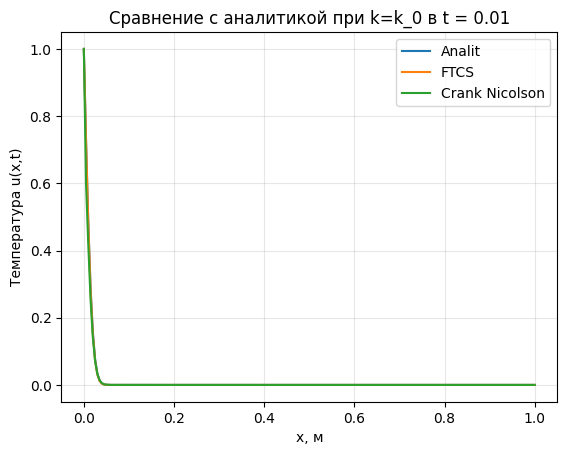

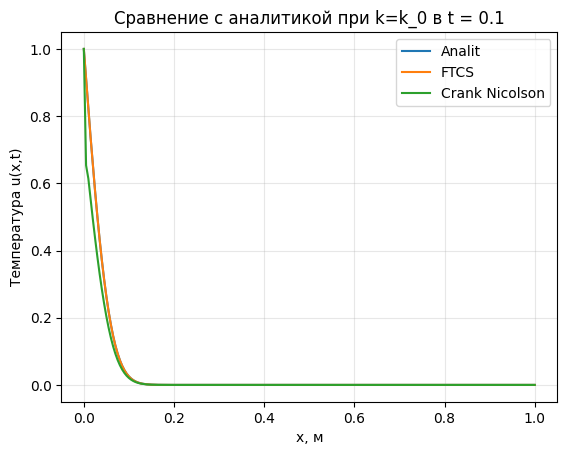

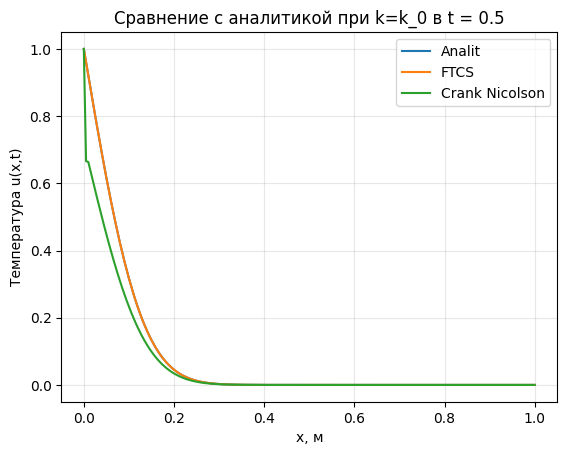

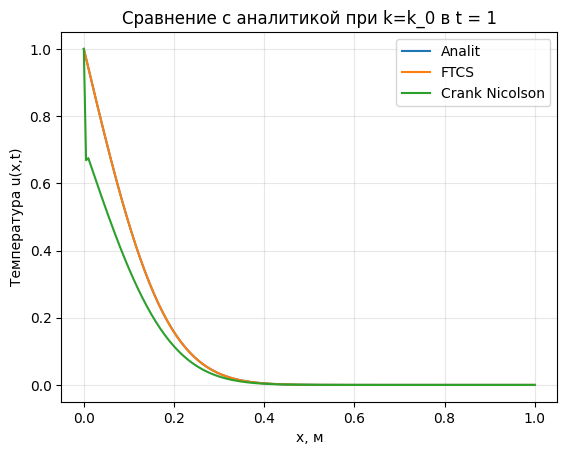

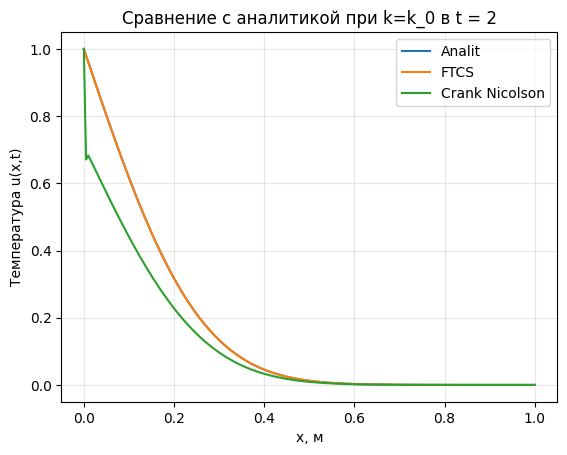

In [69]:
u_an = []
for t in t_screen:
    u_an.append( analitic( x , t , k0 , L , 100 ) )

u_ftcs = [np.zeros_like(x)]
t_start = t0
k_const = np.ones_like(x)*k0
for i in range(len(t_screen)):
    u_ftcs.append( ftcs( u_ftcs[i] , t_start , t_screen[i] , dx , dt , k_const ) )
    t_start = t_screen[i]
u_ftcs = u_ftcs[1:]

u_cn = [np.zeros_like(x)]
t_start = t0
k_const = np.ones_like(x)*k0
for i in range(len(t_screen)):
    u_cn.append( crank_nicolson( u_cn[i] , t_start , t_screen[i] , dx , dt , k_const ) )
    t_start = t_screen[i]
u_cn = u_cn[1:]

for i in range(len(t_screen)):
    plt.plot( x , u_an[i] , label=f"Analit" )
    plt.plot( x , u_ftcs[i] , label=f"FTCS" )
    plt.plot( x , u_cn[i] , label=f"Crank Nicolson" )
    
    plt.xlabel('x, м')
    plt.ylabel('Температура u(x,t)')
    plt.title(f"Сравнение с аналитикой при k=k_0 в t = {t_screen[i]}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Вычисление ошибок расчёта

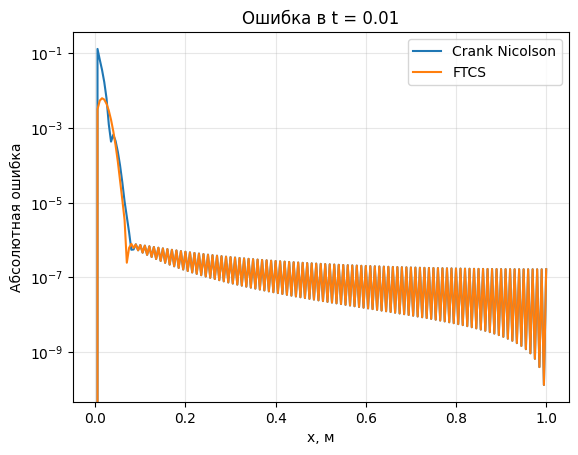

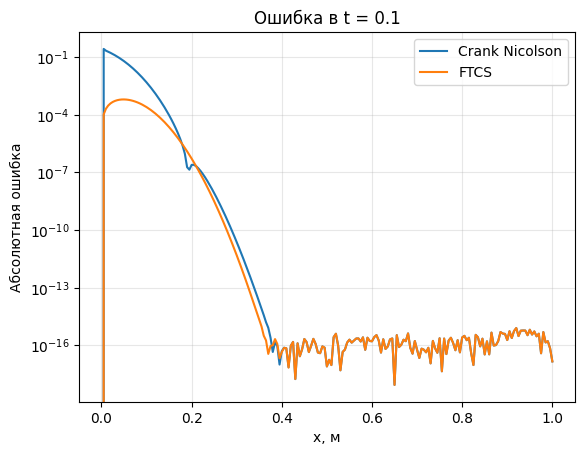

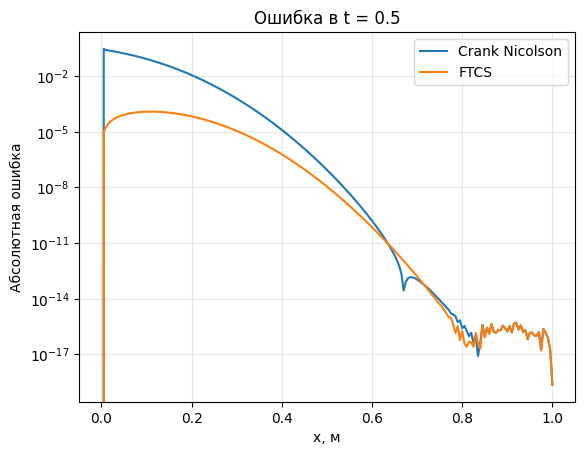

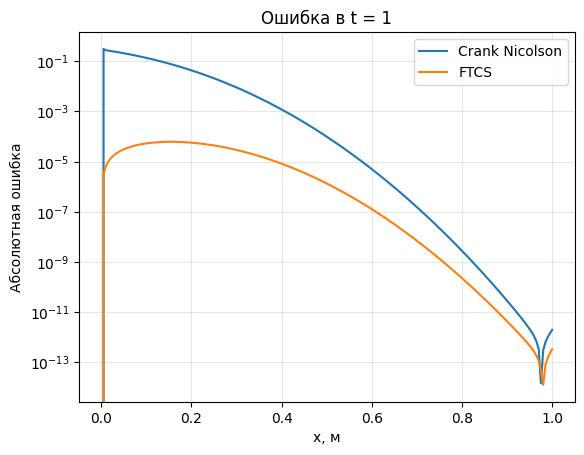

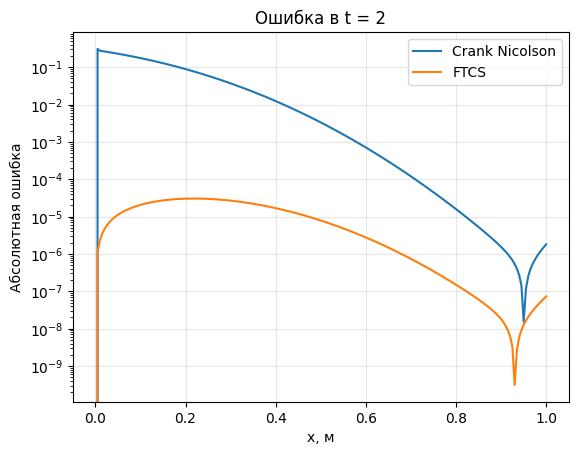

In [70]:
for i in range(len(t_screen)):
    er_ftcs = np.fabs( u_ftcs[i] - u_an[i] )
    er_cn = np.fabs( u_cn[i] - u_an[i] )
    plt.semilogy( x , er_cn   , label=f"Crank Nicolson" )
    plt.semilogy( x , er_ftcs , label=f"FTCS" )

    
    plt.xlabel('x, м')
    plt.ylabel('Абсолютная ошибка')
    plt.title(f"Ошибка в t = {t_screen[i]}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## График Энергии

/tmp/ipykernel_62089/2246970690.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_an = [ np.trapz(u_an[i],dx=dx) for i in range(len(t_screen)) ]
/tmp/ipykernel_62089/2246970690.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_ftcs = [ np.trapz(u_ftcs[i],dx=dx) for i in range(len(t_screen)) ]
/tmp/ipykernel_62089/2246970690.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_cn = [ np.trapz(u_cn[i],dx=dx) for i in range(len(t_screen)) ]


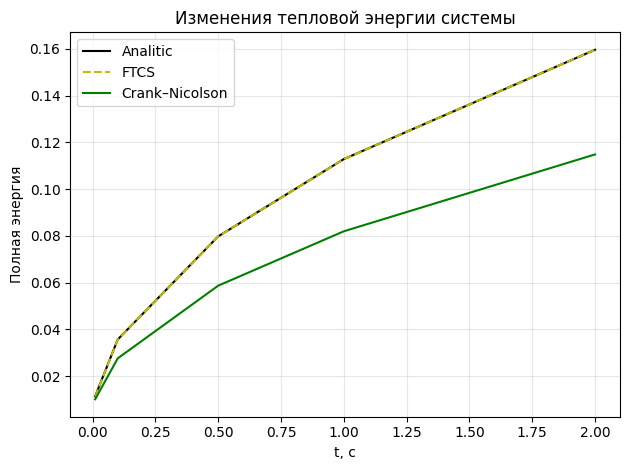

In [71]:
energy_an = [ np.trapz(u_an[i],dx=dx) for i in range(len(t_screen)) ]
energy_ftcs = [ np.trapz(u_ftcs[i],dx=dx) for i in range(len(t_screen)) ]
energy_cn = [ np.trapz(u_cn[i],dx=dx) for i in range(len(t_screen)) ]

plt.plot( t_screen , energy_an, 'k-', label='Analitic')
plt.plot( t_screen , energy_ftcs, 'y--', label='FTCS')
plt.plot( t_screen, energy_cn, 'g-', label='Crank–Nicolson')
plt.xlabel('t, с')
plt.ylabel('Полная энергия')
plt.title('Изменения тепловой энергии системы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Вычисление сходимости по Δx при фиксированном Δt согласно CFL-условию
Δx уменьшается в 2 раза с каждой новой сеткой

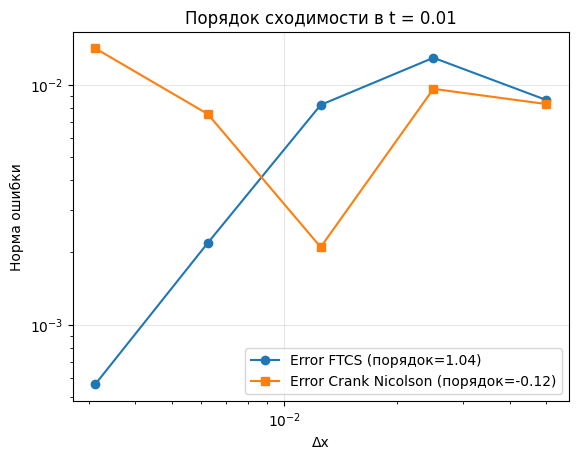

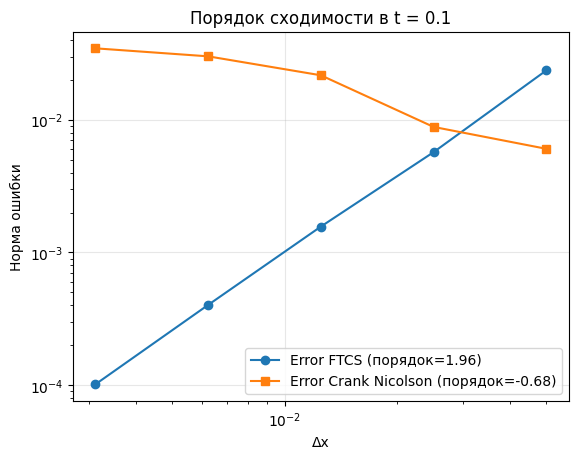

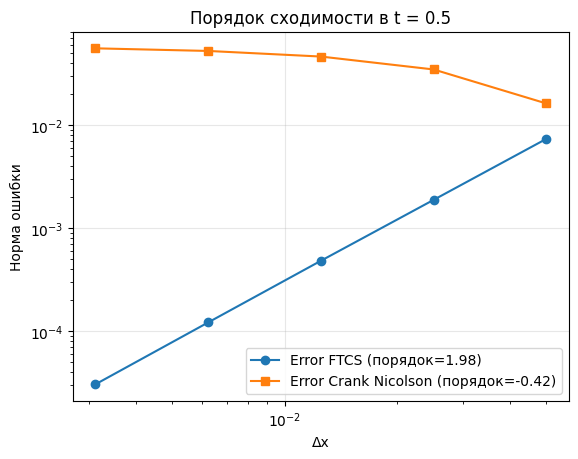

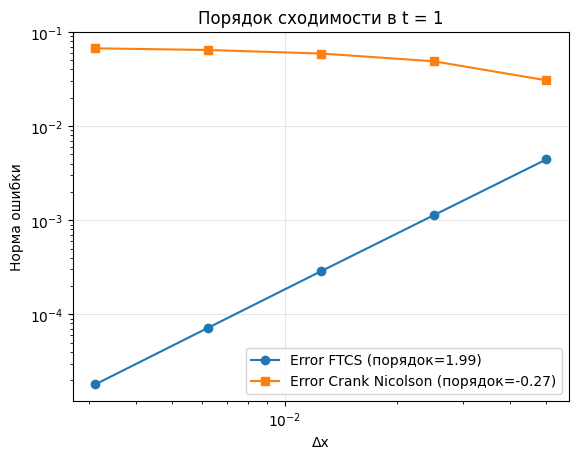

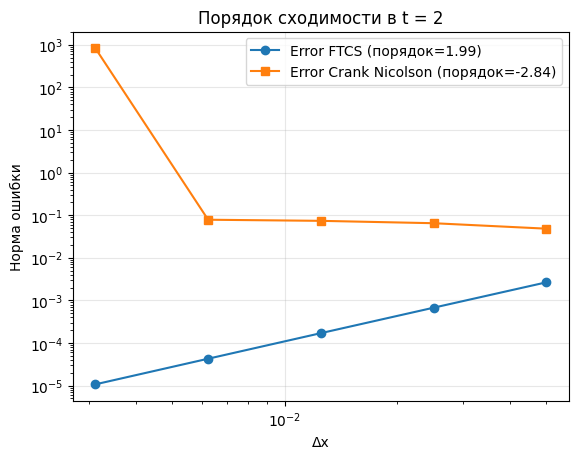

In [72]:
Nx = 21 # Начальный размер сетки
Nx_mas = [Nx , 2*(Nx-1) + 1 , 4*(Nx-1) + 1 , 8*(Nx-1) + 1 , 16*(Nx-1) + 1] # Различные размеры сеток
CFL = 0.4 # Параметр Куранта

dx_mas = L/(np.array(Nx_mas) - 1)
er_ftcs = [ [] for i in range(len(t_screen)) ]
er_cn   = [ [] for i in range(len(t_screen)) ]

u_an   = [ np.zeros(i) for i in Nx_mas ]
u_ftcs = [ np.zeros(i) for i in Nx_mas ]
u_cn   = [ np.zeros(i) for i in Nx_mas ]
for i in range(len(u_an)):
    u_an[i][0] = 1.0
    u_ftcs[i][0] = 1.0
    u_cn[i][0] = 1.0

t_start = t0
for j in range(len(t_screen)):
    t = t_screen[j]
    u_new = [ i for i in range(3)]
    for i in range(len(Nx_mas)):
        N = Nx_mas[i]
        x = np.linspace(0,L,N)
        dx = L / (N-1)
        dt = CFL *  dx**2  / k0
        k_const = np.ones_like(x)*k0
        
        u_new[0] = analitic( x , t , k0 , L , 100 )
        u_new[1] = ftcs( u_ftcs[i] , t_start , t , dx , dt , k_const )
        u_new[2] = crank_nicolson( u_cn[i] , t_start , t , dx , dt , k_const )

        u_ftcs[i] = u_new[1]
        u_cn[i]   = u_new[2]
        
        er_ftcs[j].append(np.linalg.norm(u_new[1] - u_new[0])/np.sqrt(N))
        er_cn[j].append(np.linalg.norm(u_new[2] - u_new[0])/np.sqrt(N))

    log_dx = np.log(dx_mas)
    log_err_ftcs = np.log(er_ftcs[j])
    log_err_cn = np.log(er_cn[j])
    
    p_ftcs = np.polyfit(log_dx, log_err_ftcs, 1)[0]
    p_cn = np.polyfit(log_dx, log_err_cn, 1)[0]

    plt.loglog( dx_mas , er_ftcs[j] , 'o-' , label=f"Error FTCS (порядок={p_ftcs:.2f})" )
    plt.loglog( dx_mas , er_cn[j] , 's-'  , label=f"Error Crank Nicolson (порядок={p_cn:.2f})" )
    plt.xlabel('Δx')
    plt.ylabel('Норма ошибки')
    plt.title(f"Порядок сходимости в t = {t_screen[j]}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
     
    t_start = t